In [3]:
import numpy as np

P = np.array([
    [0.9, 0.1, 0],
    [0, 0.75, 0.25],
    [0.5, 0, 0.5]
])

P50 = np.linalg.matrix_power(P, 50)

print(P50)

[[0.625 0.25  0.125]
 [0.625 0.25  0.125]
 [0.625 0.25  0.125]]


In [5]:

P = np.array([
    [1/2, 1/2, 0,   0,   0,   0],
    [1/3, 0,   1/3, 0,   1/3, 0],
    [0,   0,   1/4, 3/4, 0,   0],
    [0,   0,   1,   0,   0,   0],
    [0,   0,   0,   0,   0,   1],
    [0,   0,   0,   0,   1,   0]
])

P20 = np.linalg.matrix_power(P, 20)
P21 = np.linalg.matrix_power(P, 21)

print("P^20 ")
print(np.round(P20, 3))

print("P^21 ")
print(np.round(P21, 3))

P^20 
[[0.001 0.001 0.285 0.213 0.312 0.187]
 [0.001 0.    0.285 0.215 0.062 0.437]
 [0.    0.    0.573 0.427 0.    0.   ]
 [0.    0.    0.57  0.43  0.    0.   ]
 [0.    0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.    0.    1.   ]]
P^21 
[[0.001 0.001 0.285 0.214 0.187 0.312]
 [0.    0.    0.286 0.214 0.437 0.062]
 [0.    0.    0.57  0.43  0.    0.   ]
 [0.    0.    0.573 0.427 0.    0.   ]
 [0.    0.    0.    0.    0.    1.   ]
 [0.    0.    0.    0.    1.    0.   ]]


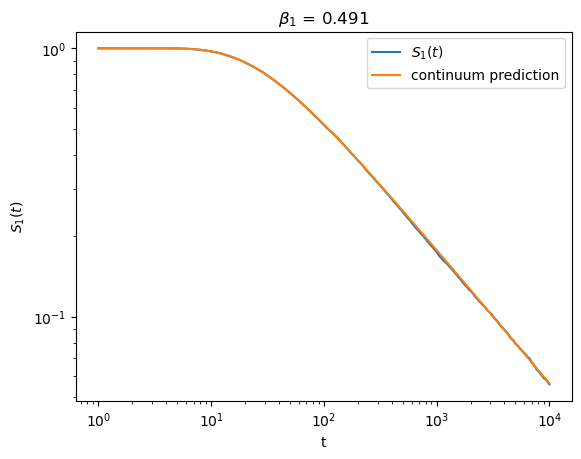

In [7]:
import matplotlib.pyplot as plt
from scipy.special import erf

R = 2 * 10**4
T = 10**4
d0 = 10

lamb = np.zeros(R, dtype=int)
lion = np.full(R, d0, dtype=int)

alive = np.ones(R, dtype=bool)

S1 = np.zeros(T + 1)
S1[0] = 1

for t in range(1, T + 1):

    lamb += np.random.choice([-1, 1], size=R)
    lion += np.random.choice([-1, 1], size=R)

    alive &= (lamb != lion)

    S1[t] = np.mean(alive)


time = np.arange(T + 1)

fit = (time >= 100) & (time <= 10000) & (S1 > 0)

slope, intercept = np.polyfit(
    np.log(time[fit]),
    np.log(S1[fit]),
    1
)

beta1 = -slope

tplot = np.arange(1, T + 1)
theory = erf(d0 / (2 * np.sqrt(tplot)))

plt.loglog(tplot, S1[1:], label="$S_1(t)$")
plt.loglog(tplot, theory, label="continuum prediction")

plt.xlabel("t")
plt.ylabel("$S_1(t)$")
plt.title(
    f"$\\beta_1$ = {beta1:.3f}"
)
plt.legend()
plt.show()

In [8]:

lamb = np.zeros(R, dtype=int)
lion1 = np.full(R, d0, dtype=int)
lion2 = np.full(R, d0, dtype=int)

alive = np.ones(R, dtype=bool)

S2 = np.zeros(T + 1)
S2[0] = 1

for t in range(1, T + 1):

    lamb += np.random.choice([-1, 1], size=R)
    lion1 += np.random.choice([-1, 1], size=R)
    lion2 += np.random.choice([-1, 1], size=R)

    alive &= (lamb != lion1) & (lamb != lion2)

    S2[t] = np.mean(alive)



fit2 = (time >= 100) & (time <= 10000) & (S2 > 0)

slope2, intercept2 = np.polyfit(
    np.log(time[fit2]),
    np.log(S2[fit2]),
    1
)

beta2 = -slope2

print("beta2 =", beta2)


print("t       S2(t)       S1(t)^2")

for t in [100, 1000, 10000]:
    print(t, S2[t], S1[t]**2)

beta2 = 0.748259469352131
t       S2(t)       S1(t)^2
100 0.34925 0.26925721
1000 0.06805 0.030275999999999997
10000 0.01185 0.00312481


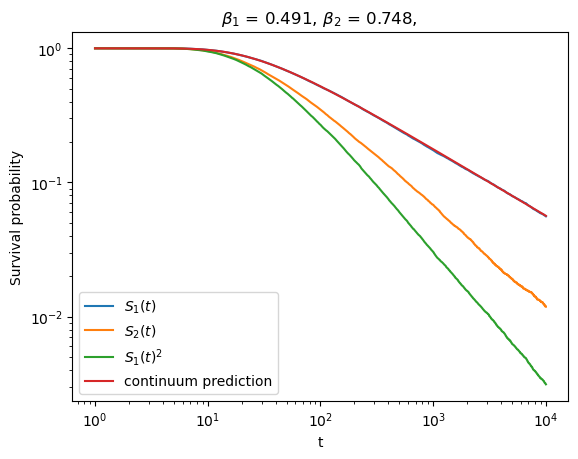

In [9]:
tplot = np.arange(1, T + 1)

plt.loglog(tplot, S1[1:], label="$S_1(t)$")
plt.loglog(tplot, S2[1:], label="$S_2(t)$")
plt.loglog(tplot, S1[1:]**2, label="$S_1(t)^2$")
plt.loglog(tplot, theory, label="continuum prediction")

plt.xlabel("t")
plt.ylabel("Survival probability")

plt.title(
    f"$\\beta_1$ = {beta1:.3f}, "
    f"$\\beta_2$ = {beta2:.3f}, "
)

plt.legend()
plt.show()